In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as mpl
import seaborn as sb
import streamlit as st
from sklearn.model_selection import train_test_split

In [6]:
df=pd.read_csv("crop_yield.csv")

In [7]:
df['Yield_tons_per_hectare'] = df['Yield_tons_per_hectare'].clip(lower=0)

In [8]:
df["Crop"]
cotton_df = df[df["Crop"] == "Cotton"]
rice_df=df[df["Crop"]=="Rice"]
barley_df=df[df["Crop"]=="Barley"]
wheat_df=df[df["Crop"]=="Wheat"]


In [10]:
df

,Region,Soil_Type,Crop,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
0,West,Sandy,Cotton,897.077239,27.676966,False,True,Cloudy,122,6.555816
1,South,Clay,Rice,992.673282,18.026142,True,True,Rainy,140,8.527341
2,North,Loam,Barley,147.998025,29.794042,False,False,Sunny,106,1.127443
3,North,Sandy,Soybean,986.866331,16.644190,False,True,Rainy,146,6.517573
4,South,Silt,Wheat,730.379174,31.620687,True,True,Cloudy,110,7.248251
...,...,...,...,...,...,...,...,...,...,...
999995,West,Silt,Rice,302.805345,27.987428,False,False,Sunny,76,1.347586
999996,South,Chalky,Barley,932.991383,39.661039,True,False,Rainy,93,7.311594
999997,North,Peaty,Cotton,867.362046,24.370042,True,False,Cloudy,108,5.763182
999998,West,Silt,Wheat,492.812857,33.045505,False,False,Sunny,102,2.070159


Text(0.5, 1.0, 'crop_variance')

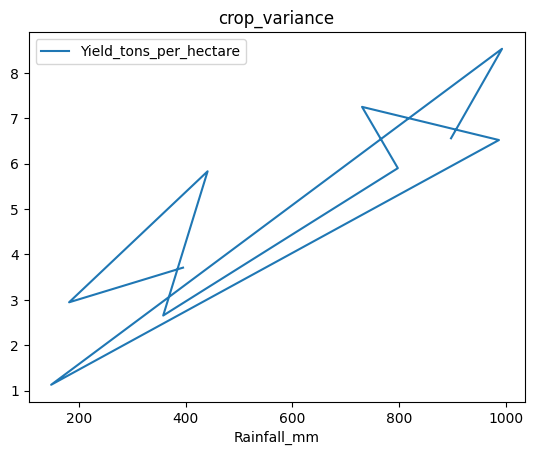

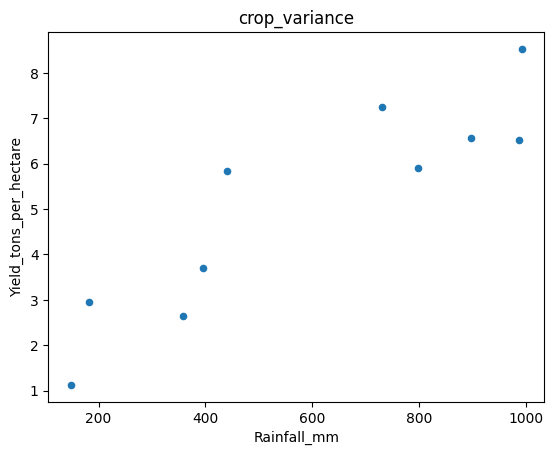

In [11]:

df.head(10).plot(x="Rainfall_mm",y="Yield_tons_per_hectare")
mpl.title("crop_variance")
df.head(10).plot(x="Rainfall_mm",y="Yield_tons_per_hectare",kind="scatter")
mpl.title("crop_variance")

In [23]:
df.describe()

,Rainfall_mm,Temperature_Celsius,Days_to_Harvest,Yield_tons_per_hectare
count,1000000.000000,1000000.000000,1000000.000000,1000000.000000
mean,549.981901,27.504965,104.495025,4.649518
std,259.851320,7.220608,25.953412,1.696443
min,100.000896,15.000034,60.000000,0.000000
25%,324.891090,21.254502,82.000000,3.417637
50%,550.124061,27.507365,104.000000,4.651808
75%,774.738520,33.753267,127.000000,5.879200
max,999.998098,39.999997,149.000000,9.963372


In [24]:
cotton_df

,Region,Soil_Type,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Weather_Condition,Days_to_Harvest,Yield_tons_per_hectare
1,West,Sandy,897.077239,27.676966,False,True,Cloudy,122,6.555816
2,East,Sandy,145.300681,19.755535,True,True,Cloudy,141,4.367612
3,South,Peaty,607.150252,15.562163,True,True,Sunny,136,6.525186
4,North,Clay,416.898632,23.190810,True,True,Sunny,95,4.858924
5,East,Clay,990.267439,24.072052,False,True,Sunny,110,6.187396
...,...,...,...,...,...,...,...,...,...
166581,North,Peaty,217.387025,27.306320,False,False,Cloudy,137,1.001849
166582,South,Loam,528.002127,37.384126,False,True,Rainy,62,3.571633
166583,North,Chalky,959.604272,32.334733,False,False,Cloudy,109,5.097432
166584,South,Loam,315.605610,30.119779,True,True,Cloudy,118,4.802915


In [9]:

cotton_df=cotton_df.drop(columns="Crop")
wheat_df=wheat_df.drop(columns="Crop")
rice_df=rice_df.drop(columns="Crop")
barley_df=barley_df.drop(columns="Crop")

In [26]:
cotton_df.index=range(1,len(cotton_df)+1)
dfc=cotton_df.drop(columns=["Region","Days_to_Harvest"])
dfc = pd.get_dummies(dfc, columns=['Weather_Condition',"Soil_Type"])
dfc=dfc.replace({True:1,False:0})

rice_df.index=range(1,len(rice_df)+1)
dfr=rice_df.drop(columns=["Region","Days_to_Harvest"])
dfr = pd.get_dummies(dfr, columns=['Weather_Condition',"Soil_Type"])
dfr=dfr.replace({True:1,False:0})

barley_df.index=range(1,len(barley_df)+1)
dfb=barley_df.drop(columns=["Region","Days_to_Harvest"])
dfb = pd.get_dummies(dfb, columns=['Weather_Condition',"Soil_Type"])
dfb=dfb.replace({True:1,False:0})

wheat_df.index=range(1,len(wheat_df)+1)
dfw=wheat_df.drop(columns=["Region","Days_to_Harvest"])
dfw = pd.get_dummies(dfw, columns=['Weather_Condition',"Soil_Type"])
dfw=dfw.replace({True:1,False:0})


C:\Users\pc\AppData\Local\Temp\ipykernel_7424\2574901791.py:4: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dfc=dfc.replace({True:1,False:0})
C:\Users\pc\AppData\Local\Temp\ipykernel_7424\2574901791.py:9: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dfr=dfr.replace({True:1,False:0})
C:\Users\pc\AppData\Local\Temp\ipykernel_7424\2574901791.py:14: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To

In [27]:
def max(data_frame):
  d=data_frame.describe()
  dfinal=d.iloc[7,4]
  otput=data_frame[data_frame["Yield_tons_per_hectare"]==dfinal]
  return otput

In [28]:
max(dfw)

,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Yield_tons_per_hectare,Weather_Condition_Cloudy,Weather_Condition_Rainy,Weather_Condition_Sunny,Soil_Type_Chalky,Soil_Type_Clay,Soil_Type_Loam,Soil_Type_Peaty,Soil_Type_Sandy,Soil_Type_Silt
77248,978.875813,35.301038,1,1,9.802534,0,1,0,0,0,0,0,1,0


In [29]:
max(dfr)

,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Yield_tons_per_hectare,Weather_Condition_Cloudy,Weather_Condition_Rainy,Weather_Condition_Sunny,Soil_Type_Chalky,Soil_Type_Clay,Soil_Type_Loam,Soil_Type_Peaty,Soil_Type_Sandy,Soil_Type_Silt
144613,980.537954,37.263468,1,1,9.963372,0,1,0,1,0,0,0,0,0


In [30]:
max(dfc)

,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Yield_tons_per_hectare,Weather_Condition_Cloudy,Weather_Condition_Rainy,Weather_Condition_Sunny,Soil_Type_Chalky,Soil_Type_Clay,Soil_Type_Loam,Soil_Type_Peaty,Soil_Type_Sandy,Soil_Type_Silt
78706,967.070702,15.765251,1,1,9.786272,0,0,1,0,0,0,0,1,0


In [31]:
max(dfb)

,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Yield_tons_per_hectare,Weather_Condition_Cloudy,Weather_Condition_Rainy,Weather_Condition_Sunny,Soil_Type_Chalky,Soil_Type_Clay,Soil_Type_Loam,Soil_Type_Peaty,Soil_Type_Sandy,Soil_Type_Silt
150993,874.775592,27.909656,1,1,9.949207,1,0,0,1,0,0,0,0,0


<Axes: >

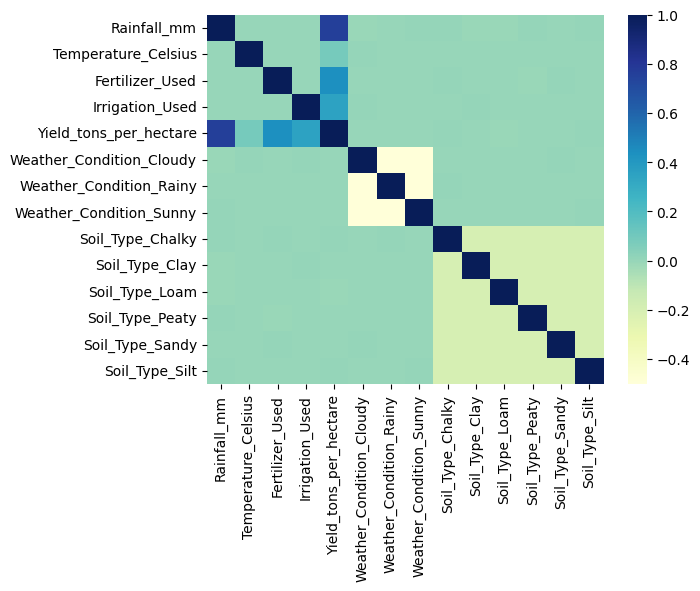

In [17]:
sb.heatmap(dfc.corr(),cmap="YlGnBu")

<Axes: >

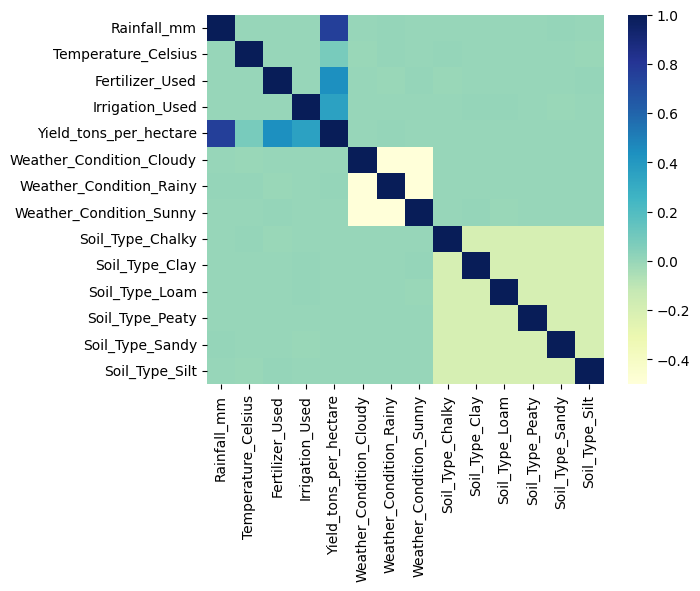

In [18]:
sb.heatmap(dfr.corr(),cmap="YlGnBu")

<Axes: >

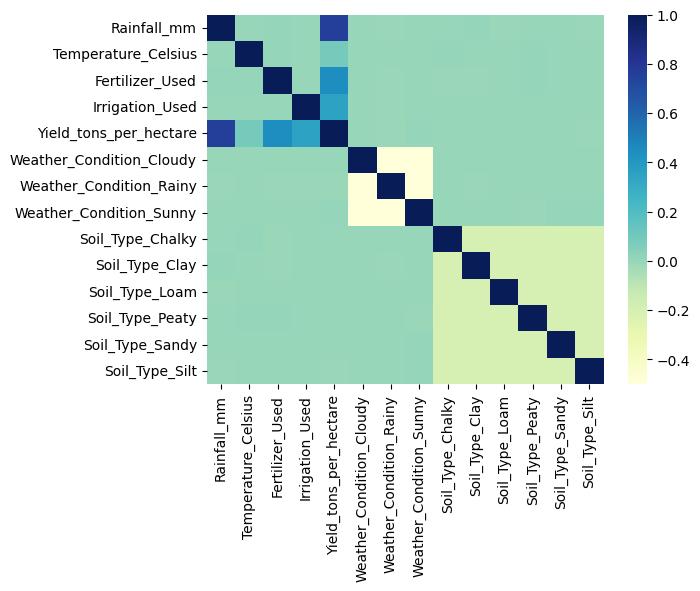

In [19]:
sb.heatmap(dfb.corr(),cmap="YlGnBu")

<Axes: >

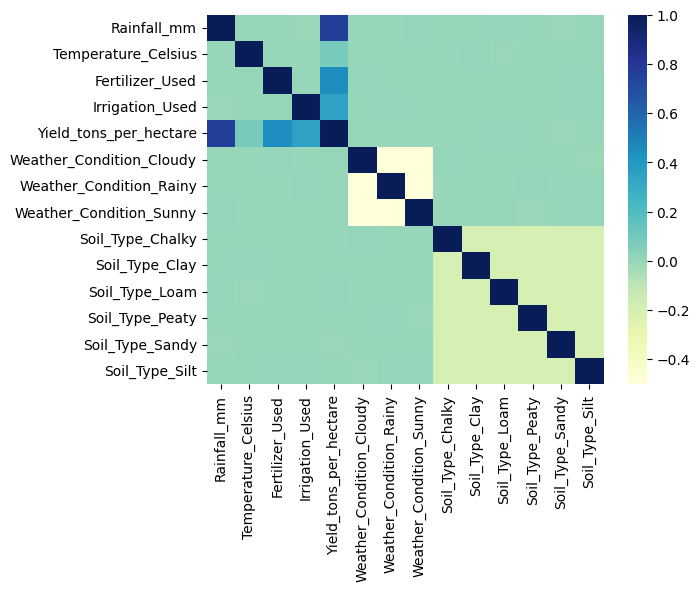

In [20]:
sb.heatmap(dfw.corr(),cmap="YlGnBu")

In [35]:
xc= dfc.drop(columns="Yield_tons_per_hectare")
yc=dfc["Yield_tons_per_hectare"]
xr= dfr.drop(columns="Yield_tons_per_hectare")
yr=dfr["Yield_tons_per_hectare"]
xw= dfw.drop(columns="Yield_tons_per_hectare")
yw=dfw["Yield_tons_per_hectare"]
xb= dfb.drop(columns="Yield_tons_per_hectare")
yb=dfb["Yield_tons_per_hectare"]

In [36]:
xc_train,xc_test,yc_train,yc_test=train_test_split(xc,yc,test_size=0.2)
xr_train,xr_test,yr_train,yr_test=train_test_split(xr,yr,test_size=0.2)
xb_train,xb_test,yb_train,yb_test=train_test_split(xb,yb,test_size=0.2)
xw_train,xw_test,yw_train,yw_test=train_test_split(xw,yw,test_size=0.2)

In [37]:
from sklearn.ensemble import RandomForestRegressor
mod_c = RandomForestRegressor()
mod_r = RandomForestRegressor()
mod_w = RandomForestRegressor()
mod_b = RandomForestRegressor()
mod_c.fit(xc_train,yc_train)
mod_r.fit(xr_train,yr_train)
mod_w.fit(xw_train,yw_train)
mod_b.fit(xb_train,yb_train)



,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""friedman_mse"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""friedman_mse"", which usesmean squared error with Friedman's improvement score for potentialsplits, ""absolute_error"" for the mean absolute error, which minimizesthe L1 loss using the median of each terminal node, and ""poisson"" whichuses reduction in Poisson deviance to find splits.Training using ""absolute_error"" is significantly slowerthan when using ""squared_error""... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion.",'squared_error'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsample

In [38]:
Dict_test = {
    "Rainfall_mm": [607.150252],
    "Temperature_Celsius": [15.562163],
    "Fertilizer_Used": [1],
    "Irrigation_Used": [1],
    "Weather_Condition_Cloudy": [0],
    "Weather_Condition_Rainy": [0],
    "Weather_Condition_Sunny": [1],
    "Soil_Type_Chalky": [0],
    "Soil_Type_Clay": [0],
    "Soil_Type_Loam": [0],
    "Soil_Type_Peaty": [1],
    "Soil_Type_Sandy": [0],
    "Soil_Type_Silt": [0],
    
}

df_test = pd.DataFrame(Dict_test)
y_new1=mod_c.predict(df_test)
y_new2=mod_r.predict(df_test)
y_new3=mod_b.predict(df_test)
y_new4=mod_w.predict(df_test)

In [39]:
f"{y_new1,y_new2,y_new3,y_new4}"

'(array([6.30488965]), array([6.13436722]), array([5.80857958]), array([5.74525575]))'

In [40]:
dfc

,Rainfall_mm,Temperature_Celsius,Fertilizer_Used,Irrigation_Used,Yield_tons_per_hectare,Weather_Condition_Cloudy,Weather_Condition_Rainy,Weather_Condition_Sunny,Soil_Type_Chalky,Soil_Type_Clay,Soil_Type_Loam,Soil_Type_Peaty,Soil_Type_Sandy,Soil_Type_Silt
1,897.077239,27.676966,0,1,6.555816,1,0,0,0,0,0,0,1,0
2,145.300681,19.755535,1,1,4.367612,1,0,0,0,0,0,0,1,0
3,607.150252,15.562163,1,1,6.525186,0,0,1,0,0,0,1,0,0
4,416.898632,23.190810,1,1,4.858924,0,0,1,0,1,0,0,0,0
5,990.267439,24.072052,0,1,6.187396,0,0,1,0,1,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
166581,217.387025,27.306320,0,0,1.001849,1,0,0,0,0,0,1,0,0
166582,528.002127,37.384126,0,1,3.571633,0,1,0,0,0,1,0,0,0
166583,959.604272,32.334733,0,0,5.097432,1,0,0,1,0,0,0,0,0
166584,315.605610,30.119779,1,1,4.802915,1,0,0,0,0,1,0,0,0


In [43]:
yc_pred=mod_c.predict(xc_test)

In [44]:
yw_pred=mod_w.predict(xw_test)

In [45]:
yb_pred=mod_b.predict(xb_test)

In [46]:
yr_pred=mod_r.predict(xr_test)

In [47]:
yc_pred

array([2.63267626, 5.12895874, 7.55908201, ..., 1.26309591, 5.13492139,
       5.66299405], shape=(33317,))

In [48]:
yc_test

91671     2.299299
66822     4.520692
122154    7.700001
113730    3.096781
55179     7.717213
            ...   
124663    5.927692
63246     7.676828
72350     1.584371
44653     5.606119
86769     5.732118
Name: Yield_tons_per_hectare, Length: 33317, dtype: float64

In [49]:
yw_pred

array([4.6639058 , 5.53051487, 5.41105003, ..., 2.27249704, 2.90786534,
       5.15135494], shape=(33335,))

In [50]:
yb_pred

array([1.83732836, 4.70992111, 2.83819432, ..., 3.34206117, 2.30237422,
       5.01488148], shape=(33356,))

In [51]:
import joblib
joblib.dump(mod_c, "cotton.joblib")
joblib.dump(mod_r, "rice.joblib")
joblib.dump(mod_w, "wheat.joblib")
joblib.dump(mod_b, "barley.joblib")

['barley.joblib']

In [53]:
import joblib 
joblib.dump(dfc,"cotton_data.joblib")
joblib.dump(dfw,"wheat_data.joblib")
joblib.dump(dfr,"rice_data.joblib")
joblib.dump(dfb,"barley_data.joblib")

['barley_data.joblib']